# 🚢 **Titanic Dataset - Exploratory Data Analysis (EDA)**

This notebook demonstrates:

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Conclusion



### 1) Primary  Objective
- The objective of this exploratory data analysis is to investigate, clean, and analyze the Titanic passenger data to uncover key factors, trends, and demographic patterns that influenced passenger survival.
- The main goal is to identify the most significant features that contributed to survival and provide insights that can be used for predictive modeling.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/competitions/titanic/data

- The data has been split into two groups:

  1-training set (train.csv)

  
  2-test set (test.csv)

- We will use the two datasets to perform our analysis and build predictive models.
- The training set contains the following columns:
- PassengerId
- Survived
- Pclass
- Name
- Sex
- Age
- SibSp
- Parch
- Ticket
- Fare
- Cabin
- Embarked
# Our target variable is 'Survived', which indicates whether a passenger survived (1) or did not survive (0).

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib and Seaborn Library.


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)



### Import the CSV data into the Pandas Dataframe

In [16]:
# we will use both train and test dataset for EDA as there are some features data that 
# is also in the test dataset which is not in the train dataset. So we will combine both datasets for EDA.

df1 = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')

# Combine datasets row-wise
df = pd.concat([df1, df2], ignore_index=True)

### Display the First five Rows

In [20]:
# Preview  of data set 
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [21]:
df2.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [22]:
df1.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [24]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
# check the shape of data set
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


### 3. Key Feature Columns Summary

| Column Name | Category / Type | Description |
| :--- | :--- | :--- |
| **PassengerId** | Numerical | Unique ID per passenger |
| **Pclass** | Categorical | Ticket class (`1` = 1st, `2` = 2nd, `3` = 3rd) |
| **Name**, **Sex**, **Age** | Demographics | Passenger profile details |
| **SibSp** | Numerical | Number of siblings / spouses aboard |
| **Parch** | Numerical | Number of parents / children aboard |
| **Ticket**, **Fare**, **Cabin** | Logistics | Ticket ID, price paid, and cabin number |
| **Embarked** | Categorical | Port of Embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton) |

# Survival is not in test dataset, so we will use train dataset for our analysis.

In [26]:
# DIfferentiate numerical and catagorical features
numerical_features=df.select_dtypes(exclude="object").columns.tolist()
catagorical_features=df.select_dtypes(include="object").columns.tolist()
print(f"Numerical features in the dataset are :{numerical_features}")
print(f"Catagorical  features in the dataset are :{catagorical_features}")

Numerical features in the dataset are :['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Catagorical  features in the dataset are :['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


### 3- Data cleaning and Preprocessing

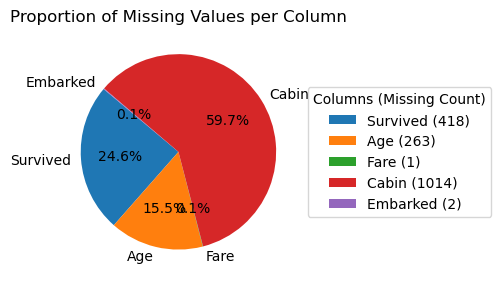

In [27]:
# Check missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

legend_labels = [f"{col} ({count})" for col, count in zip(missing_values.index, missing_values.values)]

# 3. Plot Pie Chart
plt.figure(figsize=(5,5))
ax = missing_values.plot(
    kind='pie',  
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Proportion of Missing Values per Column")
plt.ylabel("")

# Add legend with counts
plt.legend(legend_labels, title="Columns (Missing Count)", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

- we have seen that 418 values are to be predicted in the `survived`column of the test dataset. So we will use the train dataset for our analysis and build predictive models.
- The `Age` column hase 263 missing values, which we will impute with the median value of the `Age` column. 
- The `Cabin` column has 1014 missing values, where we will apply some feature engineering. 
- The `Embarked` column has 2 missing values, which we will impute with the mode value of the `Embarked` column.

In [30]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [39]:
df.shape

(1309, 12)

In [40]:
# first of all we will handle the missing values in the age column
# df["Age"].describe()
df["Age"]=df["Age"].fillna(df["Age"].median(), inplace=True)
df["Age"].isnull().sum()

c:\Users\DATA INSIGHTS\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\DATA INSIGHTS\AppData\Local\Temp\ipykernel_5160\2402942097.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"]=df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\DATA INSIGHTS\AppData\Local\Temp\ipykernel_5160\2402942097.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and wil

np.int64(1309)

Max age of the passengers is 80 years and the minimum age is 0.42 years. The average age of the passengers is 29.7 years.

# Univariate Analysis


In [ ]:
# s

148

In [ ]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Number of rows and columns
df.shape

(891, 12)

In [6]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)


Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
